In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_bbc = pd.read_csv('../data/raw/BBC-News.csv')
df_bbc.head()


,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


In [ ]:
print(f"les valurs manquantes : {df_bbc.isnull().sum()}")
print(f"les doublons : {df_bbc.duplicated().sum()}")
print(f"le nombre de catégories : {df_bbc['category'].nunique()}")
print(f"les catégories : {df_bbc['category'].unique()}")




les valurs manquantes : category    0
text        0
dtype: int64
les doublons : 99
le nombre de catégories : 5
les catégories : ['tech' 'business' 'sport' 'entertainment' 'politics']


In [10]:
df_bbc=df_bbc.drop_duplicates(subset=['text'], keep='first')
print(f"les doublons après suppression : {df_bbc.duplicated().sum()}")

les doublons après suppression : 0


In [12]:
# claculer le nombre de mots dans chaque article
df_bbc['word_count'] = df_bbc['text'].str.split().str.len()
# afficher les statistiques descriptives du nombre de mots
print(df_bbc['word_count'].describe())

count    2126.000000
mean      390.452023
std       245.118037
min        90.000000
25%       249.000000
50%       336.500000
75%       479.000000
max      4492.000000
Name: word_count, dtype: float64


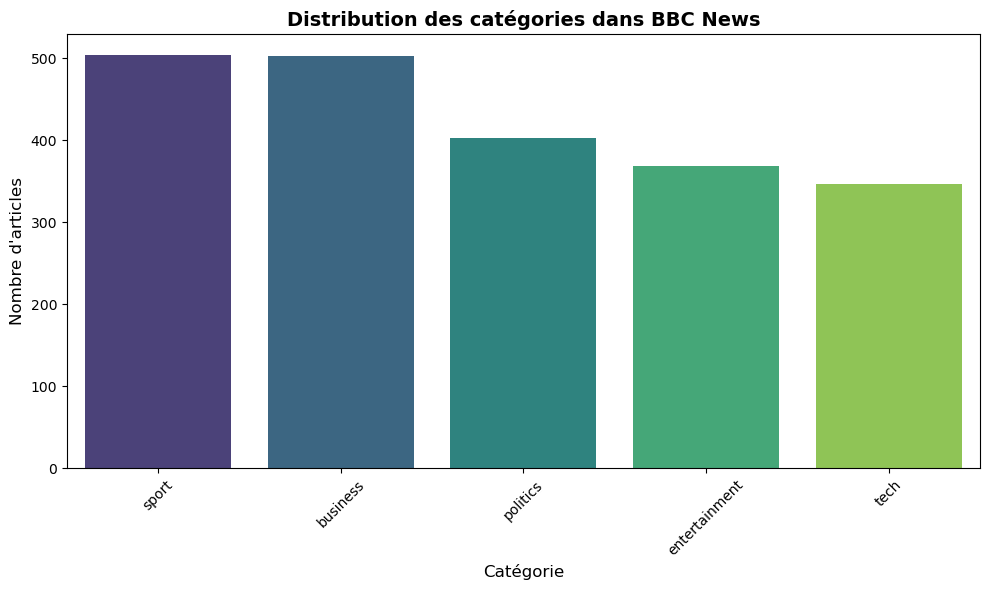

In [16]:
# Visualiser la distribution des catégories
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_bbc, 
    x='category', 
    palette='viridis', 
    order=df_bbc['category'].value_counts().index
)
plt.title('Distribution des catégories dans BBC News', fontsize=14, fontweight='bold')
plt.xlabel('Catégorie', fontsize=12)
plt.ylabel("Nombre d'articles", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/home/mouad/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


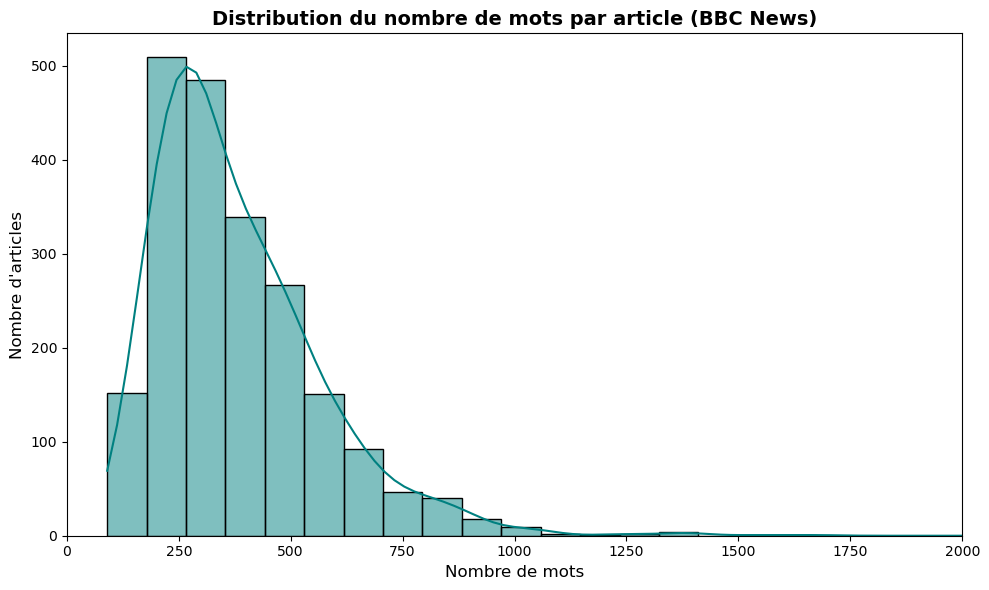

In [ ]:
# Visualiser la distribution du nombre de mots par article
plt.figure(figsize=(10, 6))
# On utilise un histplot pour voir la distribution du nombre de mots
sns.histplot(
    df_bbc['word_count'], 
    bins=50, 
    kde=True, 
    color='teal'
)
plt.title('Distribution du nombre de mots par article (BBC News)', fontsize=14, fontweight='bold')
plt.xlabel('Nombre de mots', fontsize=12)
plt.ylabel("Nombre d'articles", fontsize=12)
plt.xlim(0, 2000)  # Limiter l'axe x pour mieux visualiser la distribution
plt.tight_layout()
plt.show()

In [18]:
df_bbc.head()

,category,text,word_count
0,tech,tv future in the hands of viewers with home th...,737
1,business,worldcom boss left books alone former worldc...,300
2,sport,tigers wary of farrell gamble leicester say ...,246
3,sport,yeading face newcastle in fa cup premiership s...,341
4,entertainment,ocean s twelve raids box office ocean s twelve...,260


In [20]:
# sauvegarder le dataframe nettoyé
df_bbc.to_csv('../data/processed/BBC-News-cleaned.csv', index=False)